<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Visual-Recognition/blob/master/LAB_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Convolutional Denoising Autoencoder (MNIST)**

By the end of this lab you will be able to:

1.	Build a convolutional autoencoder for image-to-image mapping.
2.	Turn a reconstruction AE into a denoising AE (noisy → clean).
3.	Compare a learned denoiser to a classical baseline (box blur).
4.	Evaluate denoising quality with PSNR, and interpret results.
5.	Understand generalization: why a model trained at one noise level can fail at others.
6.	Implement residual learning.

Setup:

You will work on MNIST digits (28x28 grayscale). We treat denoising as a supervised mapping problem where targets are clean images but inputs are corrupted. Noise model: additive Gaussian noise.

## Imports

In [1]:
import math
from collections.abc import Callable, Sequence
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch import Tensor
from torchvision.transforms import v2

%matplotlib inline

device = torch.accelerator.current_accelerator(True) or torch.device("cpu")
print(device)

cuda


## Dataset

In [2]:
data_dir = Path("./data/MNIST/")
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
train_data = torchvision.datasets.MNIST(
    root=data_dir, train=True, download=True, transform=transform
)
test_data_all = torchvision.datasets.MNIST(
    root=data_dir, train=False, download=True, transform=transform
)

test_data = torch.utils.data.Subset(test_data_all, list(range(1000)))

num_workers = 0
batch_size = 20
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 141kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.82MB/s]


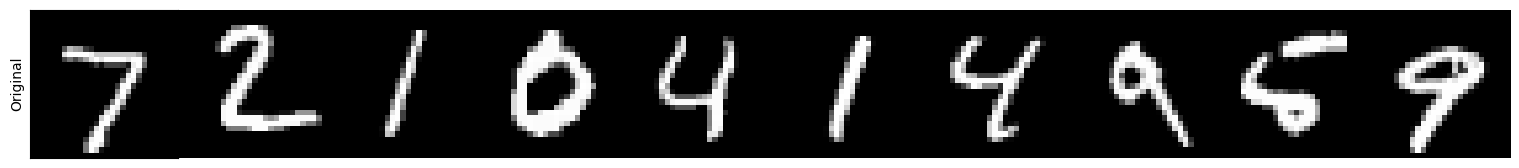

In [3]:
def show_image_batch(x: Tensor, row_title: str = "") -> None:
    fig, ax = plt.subplots(
        1,
        len(x),
        figsize=(1.5 * len(x), 1.5),
        constrained_layout=True,
        sharex=True,
        sharey=True,
    )
    fig.set_layout_engine("compressed", h_pad=0, w_pad=0, hspace=0, wspace=0)
    for i in range(len(x)):
        ax[i].imshow(np.squeeze(x[i].cpu()), cmap="gray")
        ax[i].axis("off")
    # Title left of row
    ax[0].axis("on")
    ax[0].xaxis.set_ticks([])
    ax[0].yaxis.set_ticks([])
    ax[0].set_ylabel(row_title, rotation=90)


vis_image_batch, _ = next(iter(test_loader))

show_image_batch(vis_image_batch[:10], "Original")

Let's define a function that adds zero-mean Gaussian noise with standard deviation sigma to the input images and then clips the result to keep pixel values in the [0,1] range.<br>
If `sigma` is a pair, use a different σ sampled uniformly from `sigma[0]` to `sigma[1]` for each image.

In [4]:
def corrupt_batch(
    x: Tensor, sigma: float | tuple[float, float], generator: torch.Generator
) -> Tensor:
    # TODO
    noise = torch.randn_like(x, generator=generator, device=x.device)
    if isinstance(sigma, float):
      noise = noise * sigma
    else:
      sigmas = torch.rand(x.shape[0], generator=generator, device=x.device)* (sigma[1]-sigma[0]) + sigma[0]
      noise = noise * sigmas.view(-1,1,1,1)
    x = x.clone() + noise
    x = torch.clamp(x, 0, 1)
    return x

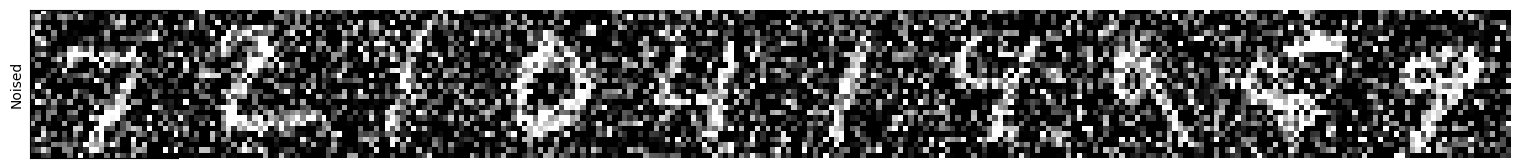

In [5]:
show_image_batch(
    corrupt_batch(vis_image_batch[:10], sigma=0.5, generator=torch.default_generator),
    "Noised",
)

## Evaluation and baseline

Let define Box Blur that applies a simple averaging filter, where each pixel is replaced by the mean of its surrounding k×k neighborhood, which smooths the image and reduces high-frequency noise but also softens edges.

In [6]:
def box_blur(x: Tensor, k: int = 3) -> Tensor:
    B, C, H, W = x.shape
    # TODO
    blur = nn.AvgPool2d(kernel_size=k, stride=1, padding=k//2)
    return blur(x)

Let's define a function to visualize model predictions on sample images:

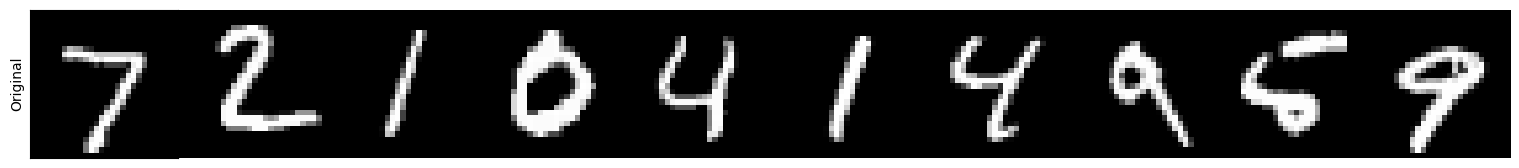

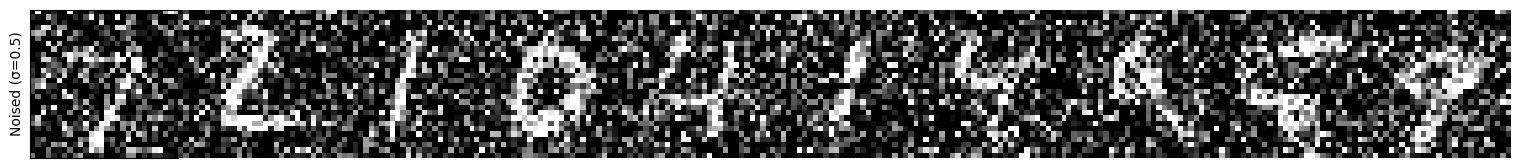

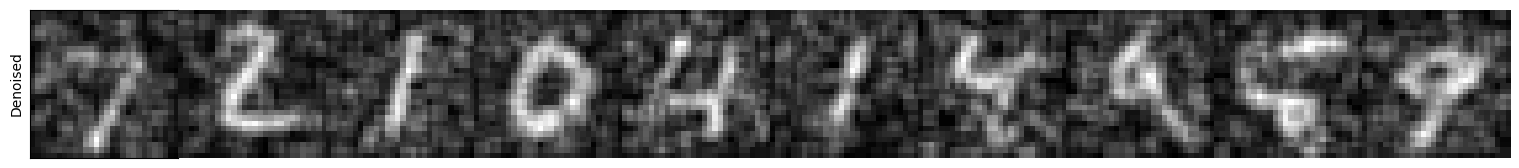

In [7]:
def visualize_model(
    model: Callable[[Tensor], Tensor], sigma: float, num_images: int = 10, seed: int = 1
) -> None:
    images, _ = next(iter(test_loader))
    images = images[:num_images].to(device)
    noisy = corrupt_batch(
        images, sigma=sigma, generator=torch.Generator(device=device).manual_seed(seed)
    )
    with torch.no_grad():
        denoised = model(noisy)
    denoised = torch.clamp(denoised, 0.0, 1.0)
    show_image_batch(images, "Original")
    show_image_batch(noisy, f"Noised (σ={sigma})")
    show_image_batch(denoised, "Denoised")


visualize_model(box_blur, sigma=0.5)

Let's define Peak Signal-to-Noise Ratio (PSNR), a quality metric derived from the mean squared error between an output image x_hat and the clean reference x; it's measured in dB and higher PSNR means the output is closer to the clean image.

In [8]:
def psnr(x_hat: Tensor, x: Tensor, max_val: float = 1.0) -> float:
    # TODO
    psnr = 20 * math.log10(max_val) - 10 * torch.log10(torch.mean((x-x_hat)**2))
    return psnr.item()

Let's define function eval_psnr_on_test_batches that tests a model across given noise levels by denoising noisy test images (optionally using residual subtraction) and printing the average PSNR for the noisy input, a box-blur baseline, and the model output against the clean images.

In [9]:
def eval_psnr_on_test_batches(
    denoiser: Callable[[Tensor], Tensor], sigmas: Sequence[float]
) -> dict[float, float]:
    results = dict[float, float]()
    for i, s in enumerate(sigmas):
        generator = torch.Generator(device=device).manual_seed(i)
        psnrs = []
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(device)
                noisy = corrupt_batch(images, sigma=s, generator=generator)
                denoised = denoiser(noisy)
                denoised = torch.clamp(denoised, 0.0, 1.0)
                psnrs.append(psnr(denoised, images))
        results[s] = float(np.mean(psnrs))
    print(", ".join(f"PSNR@σ={s} is: {results[s]:8.2f}" for s in sigmas))
    return results


all_results = dict[str, dict[float, float]]()  # Map from model name to sigma to PSNR.

In [10]:
print("Identity")
all_results["Identity"] = eval_psnr_on_test_batches(
    lambda x: x, sigmas=[0.0, 0.1, 0.2, 0.4, 0.6]
)
print("Box Blur")
all_results["Box Blur"] = eval_psnr_on_test_batches(
    box_blur, sigmas=[0.0, 0.1, 0.2, 0.4, 0.6]
)

Identity
PSNR@σ=0.0 is:      inf, PSNR@σ=0.1 is:    22.66, PSNR@σ=0.2 is:    16.74, PSNR@σ=0.4 is:    10.98, PSNR@σ=0.6 is:     8.24
Box Blur
PSNR@σ=0.0 is:    19.30, PSNR@σ=0.1 is:    18.35, PSNR@σ=0.2 is:    16.83, PSNR@σ=0.4 is:    13.78, PSNR@σ=0.6 is:    11.64


## Model

Let's build a Convolutional Denoising AutoEncoder:

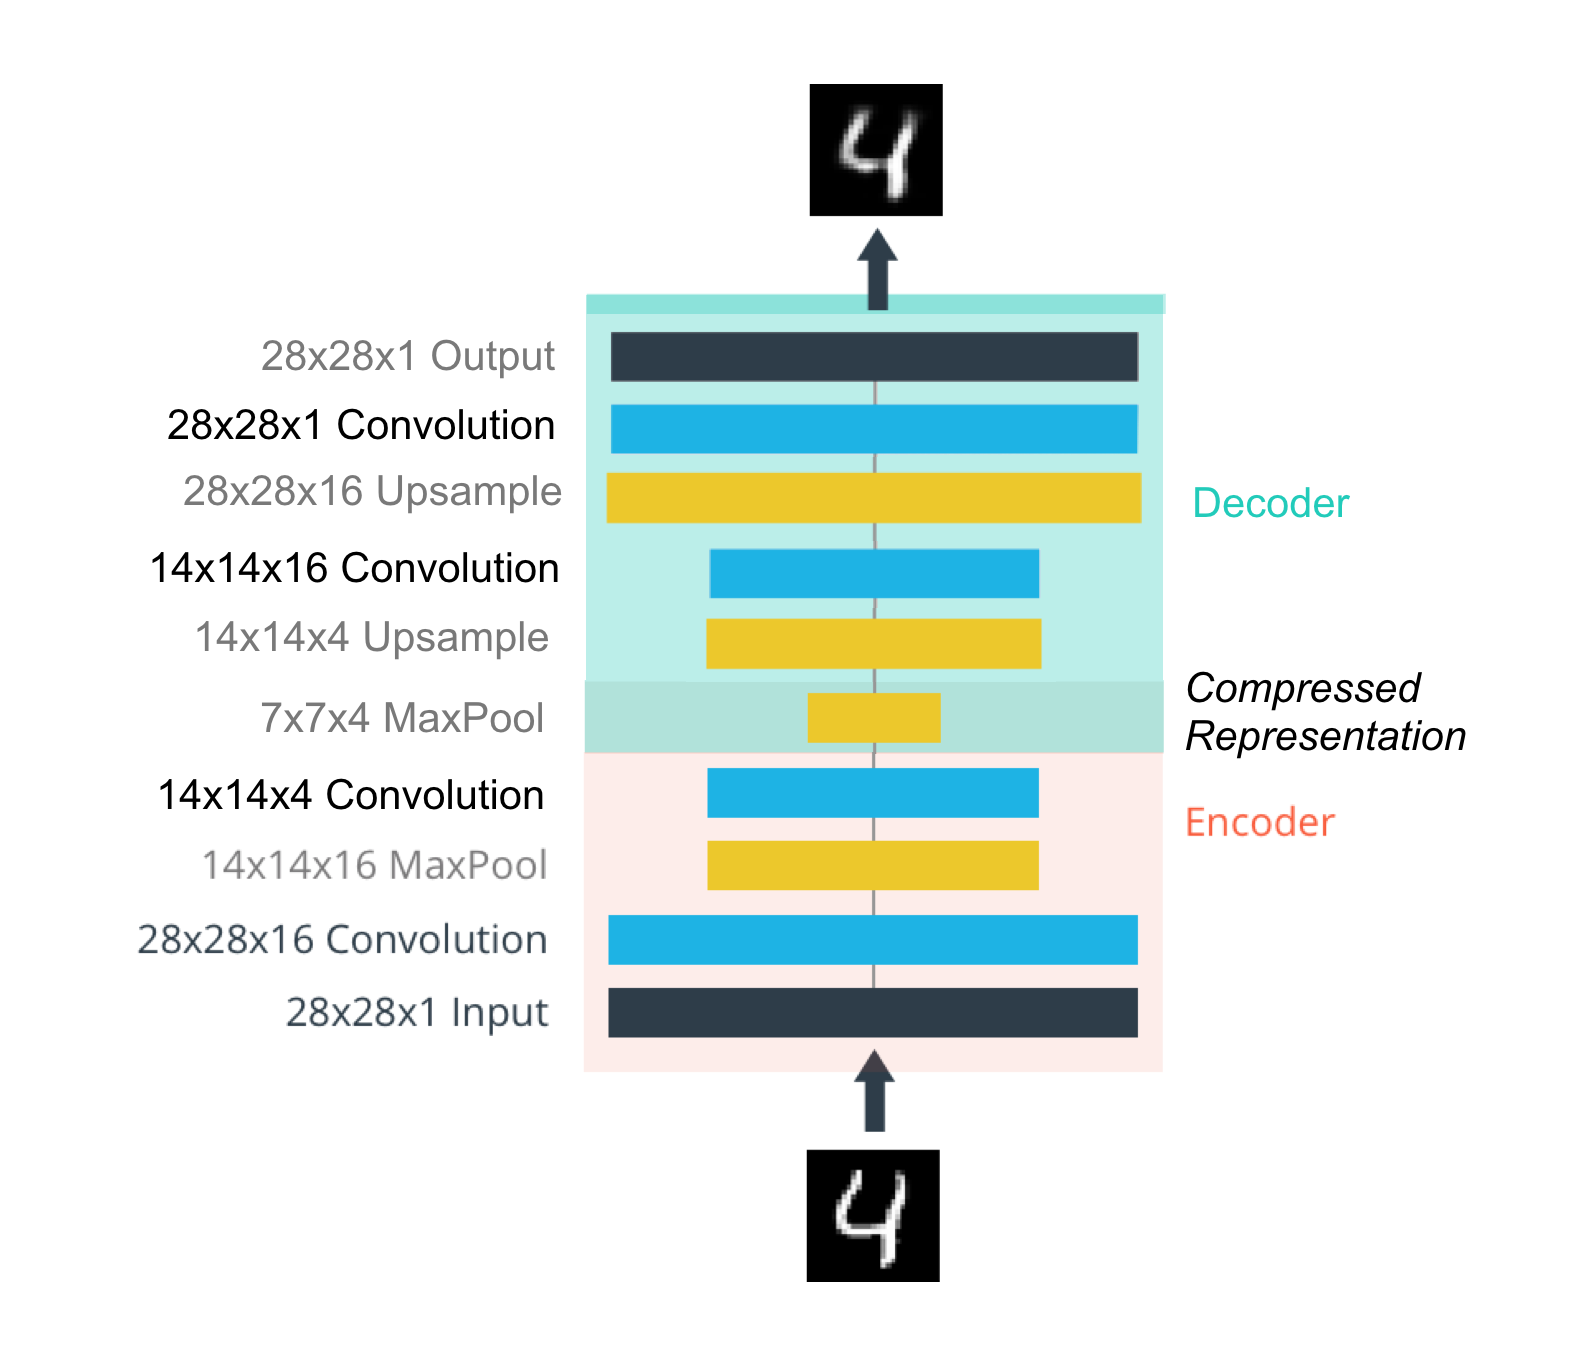

Your ConvAutoencoder consists of:
- Encoder: Conv → Pool → Conv → Pool (compression).
- Decoder: Upsample → Conv → Upsample → Conv.


What to observe:
- Pooling reduces spatial resolution and creates a bottleneck.
- The decoder restores resolution by upsampling.

In [11]:
class ConvAutoencoder(nn.Module):
    # TODO
    def __init__(self):
      super().__init__()
      self.layer_encoder = nn.Sequential(
          nn.Conv2d(1,16,3,stride=1,padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2,2),
          nn.Conv2d(16, 4, 3, stride=1,padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2, 2)
      )
      self.layer_decoder = nn.Sequential(
          nn.Upsample(scale_factor=2, mode='nearest'),
          nn.Conv2d(4, 16, 3, 1, 1),
          nn.ReLU(),
          nn.Upsample(scale_factor=2, mode='nearest'),
          nn.Conv2d(16, 1, 3, 1, 1),
          nn.Sigmoid()
      )
    def forward(self, x):
      return self.layer_decoder(self.layer_encoder(x))

PSNR@σ=0.0 is:     6.44, PSNR@σ=0.1 is:     6.45, PSNR@σ=0.2 is:     6.46, PSNR@σ=0.4 is:     6.48, PSNR@σ=0.6 is:     6.50


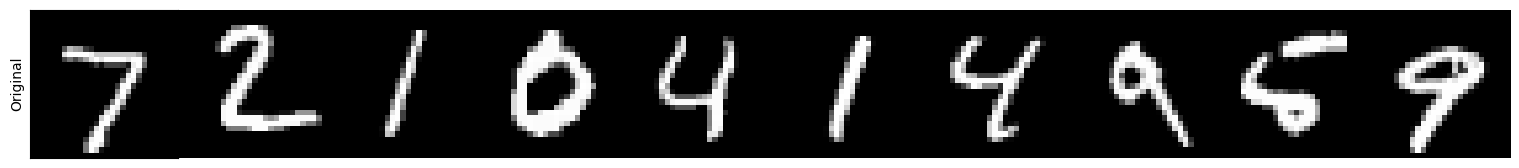

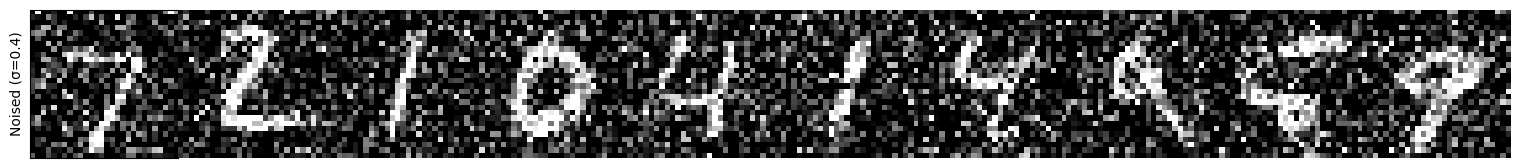

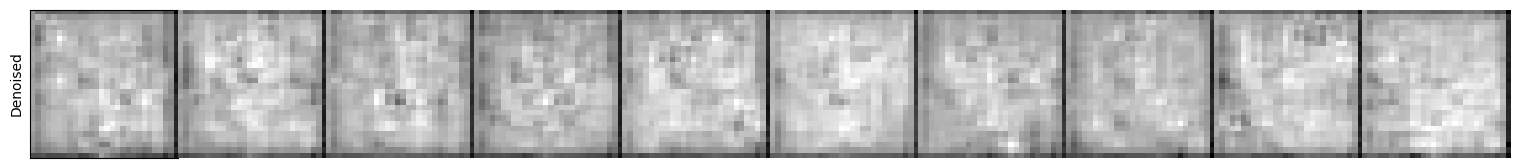

In [12]:
def call_model(model: nn.Module, x: Tensor, residual_learning: bool = False) -> Tensor:
    # TODO
    model.eval()
    if residual_learning:
      return x - model(x)
    else:
      return model(x)


eval_psnr_on_test_batches(
    partial(call_model, ConvAutoencoder().to(device)), sigmas=[0.0, 0.1, 0.2, 0.4, 0.6]
)
visualize_model(partial(call_model, ConvAutoencoder().to(device)), sigma=0.4)

## Training
Let's define training function:

In [13]:
def create_and_train_net(
    sigma: float | tuple[float, float], residual_learning: bool = False, seed: int = 1
) -> ConvAutoencoder:
    generator = torch.Generator(device=device).manual_seed(seed)
    model = ConvAutoencoder().to(device)
    model.train()

    if residual_learning:
        # TODO
        raise NotImplementedError()

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    n_epochs = 30
    for epoch in range(1, n_epochs + 1):
        total_loss, total_images = 0.0, 0
        for data in train_loader:
            images, _ = data
            images = images.to(device)
            noisy_images = corrupt_batch(images, sigma, generator)
            optimizer.zero_grad()

            pred = model(noisy_images)
            loss = nn.MSELoss()(pred, images)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
            total_images += images.size(0)

        avg_loss = total_loss / total_images
        print(f"Epoch: {epoch} \tTraining Loss: {avg_loss:.6f}")

    return model

Let's train a model only on Gaussian noise with σ = 0.4, so it becomes a "specialist" for that noise strength.

In [14]:
model1 = create_and_train_net(sigma=0.4)

Epoch: 1 	Training Loss: 0.023287
Epoch: 2 	Training Loss: 0.014727
Epoch: 3 	Training Loss: 0.013865
Epoch: 4 	Training Loss: 0.013474
Epoch: 5 	Training Loss: 0.013172
Epoch: 6 	Training Loss: 0.012990
Epoch: 7 	Training Loss: 0.012821
Epoch: 8 	Training Loss: 0.012717
Epoch: 9 	Training Loss: 0.012651
Epoch: 10 	Training Loss: 0.012581
Epoch: 11 	Training Loss: 0.012504
Epoch: 12 	Training Loss: 0.012449
Epoch: 13 	Training Loss: 0.012376
Epoch: 14 	Training Loss: 0.012297
Epoch: 15 	Training Loss: 0.012258
Epoch: 16 	Training Loss: 0.012200
Epoch: 17 	Training Loss: 0.012134
Epoch: 18 	Training Loss: 0.012077
Epoch: 19 	Training Loss: 0.012034
Epoch: 20 	Training Loss: 0.011981
Epoch: 21 	Training Loss: 0.011954
Epoch: 22 	Training Loss: 0.011913
Epoch: 23 	Training Loss: 0.011896
Epoch: 24 	Training Loss: 0.011856
Epoch: 25 	Training Loss: 0.011834
Epoch: 26 	Training Loss: 0.011814
Epoch: 27 	Training Loss: 0.011815
Epoch: 28 	Training Loss: 0.011805
Epoch: 29 	Training Loss: 0.0

PSNR@σ=0.0 is:    21.72, PSNR@σ=0.1 is:    21.68, PSNR@σ=0.2 is:    21.27, PSNR@σ=0.4 is:    19.38, PSNR@σ=0.6 is:    16.09


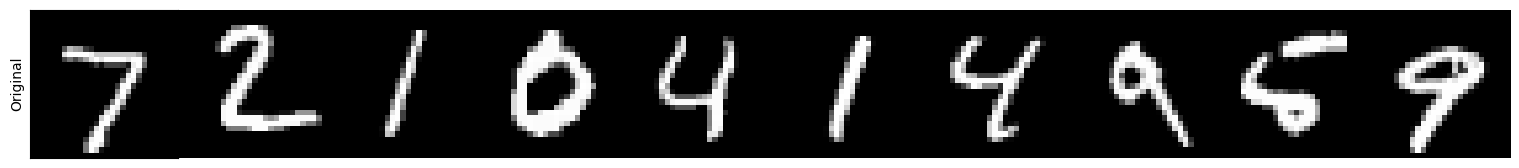

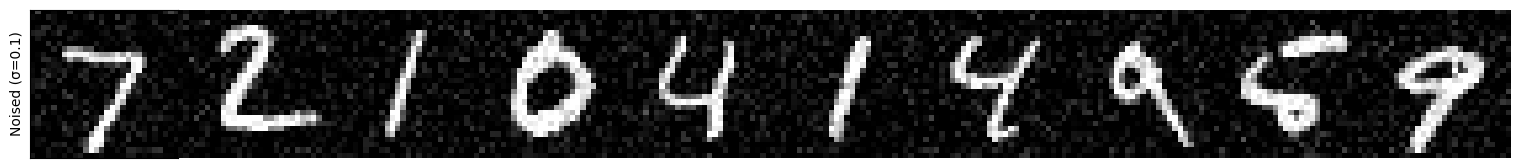

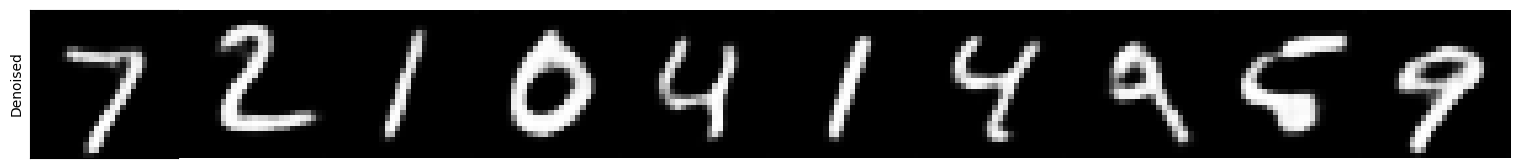

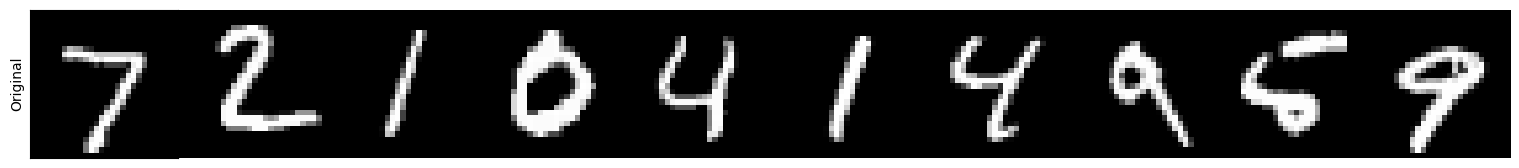

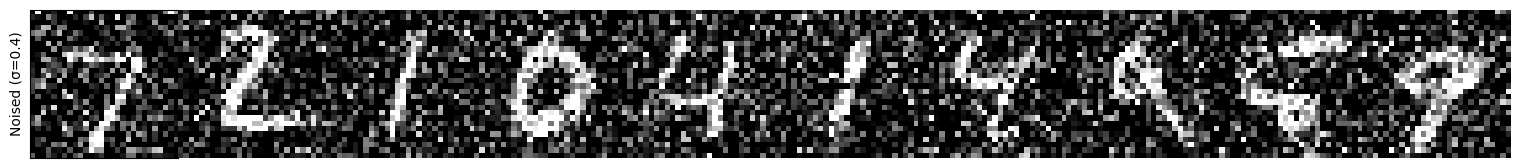

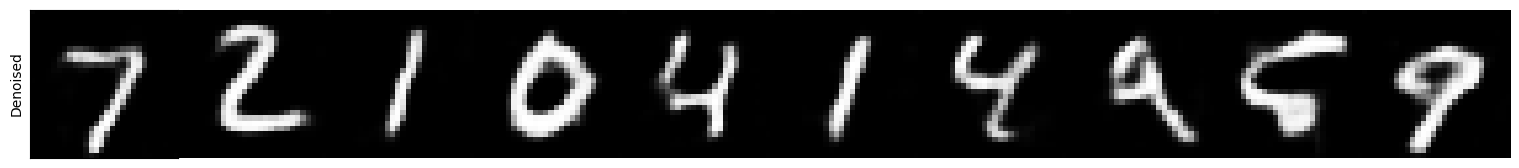

In [15]:
all_results["Model1 (σ=0.4)"] = eval_psnr_on_test_batches(
    partial(call_model, model1), sigmas=[0.0, 0.1, 0.2, 0.4, 0.6]
)
visualize_model(partial(call_model, model1), sigma=0.1)
visualize_model(partial(call_model, model1), sigma=0.4)

Let's train a model on different noise strengths per image (σ sampled uniformly from 0 to 0.6), so it learns a more robust "blind denoiser" rather than a σ=0.4 specialist.

In [ ]:
model2 = create_and_train_net(sigma=(0, 0.6))

Epoch: 1 	Training Loss: 0.112752
Epoch: 2 	Training Loss: 0.112003
Epoch: 3 	Training Loss: 0.112003
Epoch: 4 	Training Loss: 0.112003
Epoch: 5 	Training Loss: 0.112003
Epoch: 6 	Training Loss: 0.112003
Epoch: 7 	Training Loss: 0.112003
Epoch: 8 	Training Loss: 0.112003
Epoch: 9 	Training Loss: 0.112003
Epoch: 10 	Training Loss: 0.112003
Epoch: 11 	Training Loss: 0.112003
Epoch: 12 	Training Loss: 0.112003
Epoch: 13 	Training Loss: 0.112003
Epoch: 14 	Training Loss: 0.112003
Epoch: 15 	Training Loss: 0.112003
Epoch: 16 	Training Loss: 0.112003
Epoch: 17 	Training Loss: 0.112003
Epoch: 18 	Training Loss: 0.112003
Epoch: 19 	Training Loss: 0.112003
Epoch: 20 	Training Loss: 0.112003
Epoch: 21 	Training Loss: 0.112003
Epoch: 22 	Training Loss: 0.112003
Epoch: 23 	Training Loss: 0.112003
Epoch: 24 	Training Loss: 0.112003


In [ ]:
all_results["Model2 (σ=0–0.6)"] = eval_psnr_on_test_batches(
    partial(call_model, model2), sigmas=[0.0, 0.1, 0.2, 0.4, 0.6]
)
visualize_model(partial(call_model, model2), sigma=0.1)
visualize_model(partial(call_model, model2), sigma=0.4)

Residual learning: instead of predicting the clean image, let's train the network to predict the residual (noise) r = noisy − clean.
Modify the training loop and the `call_model` wrapper accordingly.

In [ ]:
model3 = create_and_train_net(sigma=(0, 0.6), residual_learning=True)

In [ ]:
all_results["Model3 (residual, σ=0–0.6)"] = eval_psnr_on_test_batches(
    partial(call_model, model3, residual_learning=True),
    sigmas=[0.0, 0.1, 0.2, 0.4, 0.6],
)
visualize_model(partial(call_model, model3, residual_learning=True), sigma=0.1)
visualize_model(partial(call_model, model3, residual_learning=True), sigma=0.4)

## Plot

Let's plot results:

In [ ]:
def plot_all_results(all_results: dict[str, dict[float, float]]):
    plt.figure(figsize=(8, 6))

    styles = ["k--", "gray", "o-", "s-", "^-", "d-", "x-"]
    for (model_name, results), style in zip(all_results.items(), styles):
        plt.plot(list(results.keys()), list(results.values()), style, label=model_name)

    plt.axvline(0.4, linestyle="--", alpha=0.3)

    plt.xlabel("Noise level σ")
    plt.ylabel("PSNR (dB)")
    plt.title("Denoising performance vs noise level")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_all_results(all_results)